# 📰 Clickbait Detection with Snorkel
### Part 3 of 3: Data Slicing, or Where Does Weak Supervision Fail?

A model with good **overall** accuracy can still fail badly on particular **subgroups (slices)** of the data. In a production system those failures matter, because they're often concentrated on exactly the inputs users care about.

In Part 1 we trained a clickbait classifier on **weak labels** from labeling functions and got about 94% test accuracy, about 3 points below the same model trained on gold labels. In this part we ask: **is that 3-point gap spread evenly, or concentrated in specific kinds of headlines?**

We'll:
1. Define **slicing functions (SFs)** for headline subgroups.
2. **Monitor** per-slice performance of the weak-label model vs. a gold-label model.
3. Trace the gaps back to **label quality** in those slices.
4. Try to **improve** the weak slices with Snorkel's `SliceAwareClassifier`, choosing hyperparameters on the **validation set** and comparing against a plain MLP of the same architecture.

**What's different from the reference YouTube-spam tutorial**

| | Reference lab | This lab |
|---|---|---|
| Training labels | gold labels | **weak labels produced in Part 1** (loaded from disk) |
| Slices | short comment, "please", "check out", `.ly` links, polarity | **7 headline slices**: short, listicle, question, Title Case, quotes, person mentions (spaCy), numbers mid-headline |
| Monitoring | one model | **weak-label vs. gold-label model**, per-slice gap chart, root-cause analysis on label quality |
| Slice-aware model | vs. a LogisticRegression; 2 epochs | vs. an **identical MLP without slice heads**; hyperparameters picked on **valid**, **3 seeds** on test |

In [1]:
import logging
import os
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

os.environ["PYTHONHASHSEED"] = "0"
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

logging.getLogger().setLevel(logging.WARNING)
pd.set_option("display.max_colwidth", 90)

## 0. Loading data and the Part 1 weak labels

`weak_labels_train.csv` was written by Part 1: one row per training headline that at least one LF labeled, with the LabelModel's prediction. We also attach the **gold** label of each headline so we can measure label quality and train a gold-label reference model.

In [2]:
from utils import load_clickbait_dataset

WEAK_LABELS_PATH = "data/clickbait/weak_labels_train.csv"
assert os.path.exists(WEAK_LABELS_PATH), "Run 01_clickbait_labeling.ipynb first to create the weak labels."

df_gold_train, _, df_valid, df_test = load_clickbait_dataset(load_train_labels=True, split_dev_valid=True)
weak = pd.read_csv(WEAK_LABELS_PATH)

df_train = weak.merge(df_gold_train[["text", "label"]], on="text", how="left")
assert df_train.label.notna().all()

Y_weak = df_train.weak_label.values
Y_gold = df_train.label.values
Y_valid = df_valid.label.values
Y_test = df_test.label.values

print(f"train (weakly labeled): {len(df_train):,}  valid: {len(df_valid):,}  test: {len(df_test):,}")
print(f"Weak-label accuracy vs. gold on train: {(Y_weak == Y_gold).mean() * 100:.1f}%")

train (weakly labeled): 27,009  valid: 1,000  test: 2,000
Weak-label accuracy vs. gold on train: 96.0%


## 1. Writing slicing functions

A slicing function looks like a labeling function, but it returns `True`/`False` (is this headline in the slice?) instead of a label. We pick slices that are **meaningful for a clickbait product**, where a mistake would be visible or costly:

| SF | Why we care |
|---|---|
| `short_headline` | ≤ 5 words, so there's very little text to go on |
| `starts_with_number` | listicles: the most recognisable clickbait format |
| `is_question` | quiz headlines ("Which Friends Character Are You") |
| `title_case` | Every Word Capitalised. Related to the **style shortcut** from Part 1, where our NEWS LF relied on lowercase function words |
| `has_quote` | quoted titles/speech: shared by news ("PM calls deal 'historic'") and clickbait ("33 'Mean Girls' Quotes") |
| `mentions_person` | celebrities (clickbait) vs. politicians (news), detected with spaCy NER |
| `has_number_mid` | a number not at the start: news counts ("kills 12") vs. listicles |

In [3]:
from snorkel.slicing import slicing_function
from snorkel.slicing.sf.nlp import nlp_slicing_function


@slicing_function()
def short_headline(x):
    return len(x.text.split()) <= 5


@slicing_function()
def starts_with_number(x):
    return bool(re.match(r"^\d+\s", x.text))


@slicing_function()
def is_question(x):
    return "?" in x.text or bool(
        re.match(r"^(how|why|what|which|who|can|do|does|is|are|should)\b", x.text, flags=re.I)
    )


@slicing_function()
def title_case(x):
    words = [w for w in x.text.split()[1:] if w[:1].isalpha()]
    return len(words) >= 3 and all(w[:1].isupper() for w in words)


@slicing_function()
def has_quote(x):
    return bool(re.search(r"[\"“”]|(^|\s)'\w", x.text))


@nlp_slicing_function()
def mentions_person(x):
    return any(ent.label_ == "PERSON" for ent in x.doc.ents)


@slicing_function()
def has_number_mid(x):
    return bool(re.search(r"\s\d+", x.text)) and not re.match(r"^\d", x.text)


sfs = [
    short_headline,
    starts_with_number,
    is_question,
    title_case,
    has_quote,
    mentions_person,
    has_number_mid,
]
slice_names = [sf.name for sf in sfs]

`slice_dataframe` lets us look inside a slice:

In [4]:
from snorkel.slicing import slice_dataframe

slice_dataframe(df_test, has_quote)[["text", "label"]].head(8)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:00<00:00, 176676.66it/s]

,text,label
8,"Someone Switched Gordon Ramsay's Lines From ""MasterChef Junior"" With ""Hell's Kitchen""",1
10,"This Guy Watched All Of ""Breaking Bad"" For Three Days Straight And It's An Emotional R...",1
19,"Dear ""Walking Dead"": You Just Killed The Wrong Person",1
32,"After Seven Years, Someone Finally Completed ""American Ninja Warrior's"" Final Course",1
90,"Will Ferrell Is Now An Exotic Animal Expert For ""The Late Show""",1
115,New gambling review could jeopardize UK's 'supercasino' plans,0
124,"UK Transport Minister ""pied"" during launch of Future Heathrow group",0
151,"Times Of India Called Alan Rickman The Villain Of The ""Harry Potter"" Series In His Obi...",1


Now we apply all SFs to every split. The output `S` is a record array with one boolean field per slice. This takes about a minute because `mentions_person` runs spaCy.

In [5]:
from snorkel.slicing import PandasSFApplier

applier = PandasSFApplier(sfs)
S_train = applier.apply(df_train)
S_valid = applier.apply(df_valid)
S_test = applier.apply(df_test)

slice_stats = pd.DataFrame(
    {
        "test_size": [S_test[n].sum() for n in slice_names],
        "test_%_clickbait": [Y_test[S_test[n].astype(bool)].mean() * 100 for n in slice_names],
    },
    index=slice_names,
).round(1)
slice_stats

  0%|          | 0/27009 [00:00<?, ?it/s]

  0%|          | 36/27009 [00:00<01:16, 352.12it/s]

  0%|          | 75/27009 [00:00<01:12, 370.03it/s]

  0%|          | 113/27009 [00:00<01:36, 278.19it/s]

  1%|          | 153/27009 [00:00<01:24, 317.16it/s]

...

 94%|█████████▍| 1875/2000 [00:04<00:00, 445.68it/s]

 96%|█████████▌| 1920/2000 [00:04<00:00, 443.97it/s]

 98%|█████████▊| 1966/2000 [00:04<00:00, 445.30it/s]

100%|██████████| 2000/2000 [00:04<00:00, 446.86it/s]

,test_size,test_%_clickbait
short_headline,137,28.5
starts_with_number,400,92.2
is_question,217,95.9
title_case,1045,94.2
has_quote,166,83.1
mentions_person,404,41.1
has_number_mid,179,31.3


## 2. Monitoring slice performance

We train the **same** pipeline from Part 1 (TF-IDF 1–2-grams + linear model) twice on the same headlines: once on the **weak labels**, once on the **gold labels**. We use `LogisticRegression` here because it gives probabilities, which Snorkel's `Scorer` can use.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from snorkel.analysis import Scorer
from snorkel.utils import preds_to_probs

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_sparse = vectorizer.fit_transform(df_train.text)
X_test_sparse = vectorizer.transform(df_test.text)

scorer = Scorer(metrics=["accuracy", "f1"])


def score_model(model):
    preds = model.predict(X_test_sparse)
    return scorer.score_slices(
        S=S_test, golds=Y_test, preds=preds, probs=preds_to_probs(preds, 2), as_dataframe=True
    )


weak_lr = LogisticRegression(C=10, max_iter=2000).fit(X_train_sparse, Y_weak)
gold_lr = LogisticRegression(C=10, max_iter=2000).fit(X_train_sparse, Y_gold)

weak_scores = score_model(weak_lr)
gold_scores = score_model(gold_lr)
weak_scores

,accuracy,f1
overall,0.940500,0.937664
short_headline,0.897810,0.794118
starts_with_number,0.985000,0.991826
is_question,0.981567,0.990431
title_case,0.903349,0.946018
has_quote,0.873494,0.918288
mentions_person,0.908416,0.876254
has_number_mid,0.949721,0.912621


Overall the weak-label model looks fine, but some slices are clearly worse. Let's put it side by side with the gold-label model:

In [7]:
monitor = pd.DataFrame(
    {
        "weak_label_acc_%": weak_scores["accuracy"] * 100,
        "gold_label_acc_%": gold_scores["accuracy"] * 100,
    }
)
monitor["gap_pts"] = monitor["gold_label_acc_%"] - monitor["weak_label_acc_%"]
monitor = monitor.round(1).sort_values("gap_pts", ascending=False)
monitor

,weak_label_acc_%,gold_label_acc_%,gap_pts
has_quote,87.3,97.6,10.2
title_case,90.3,96.5,6.1
short_headline,89.8,94.9,5.1
mentions_person,90.8,95.8,5.0
overall,94.0,97.4,3.3
has_number_mid,95.0,97.2,2.2
is_question,98.2,98.6,0.5
starts_with_number,98.5,98.8,0.2


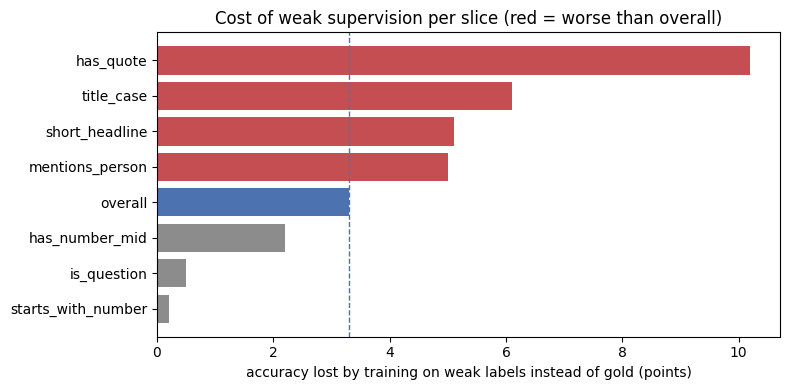

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C44E52" if g > monitor.loc["overall", "gap_pts"] else "#8c8c8c" for g in monitor["gap_pts"]]
colors = ["#4C72B0" if n == "overall" else c for n, c in zip(monitor.index, colors)]
ax.barh(monitor.index, monitor["gap_pts"], color=colors)
ax.axvline(monitor.loc["overall", "gap_pts"], color="#4C72B0", ls="--", lw=1)
ax.invert_yaxis()
ax.set_xlabel("accuracy lost by training on weak labels instead of gold (points)")
ax.set_title("Cost of weak supervision per slice (red = worse than overall)")
plt.tight_layout()
plt.show()

**The cost of weak supervision is not uniform.** A few slices lose two to three times as many points as the overall number suggests. A dashboard that only shows overall accuracy would hide this.

Let's look at some mistakes the weak-label model makes in the worst slice:

In [9]:
worst_slice = monitor.drop("overall").index[0]
mask = S_test[worst_slice].astype(bool)
errors = df_test[mask].assign(pred=weak_lr.predict(X_test_sparse[mask]))
errors = errors[errors.pred != errors.label]
print(f"Worst slice: {worst_slice}  ({len(errors)} errors out of {mask.sum()} headlines)")
errors[["text", "label", "pred"]].head(10)

Worst slice: has_quote  (21 errors out of 166 headlines)


,text,label,pred
19,"Dear ""Walking Dead"": You Just Killed The Wrong Person",1,0
32,"After Seven Years, Someone Finally Completed ""American Ninja Warrior's"" Final Course",1,0
180,"Did Anyone Else Notice Visible Penis In ""The Martian""",1,0
391,"The ""Secret Sister"" Gift Exchange On Facebook Is Very Illegal And Also A Hoax",1,0
467,"There's A New Hairstyle Called The ""Hun"" And It's Taking Over",1,0
535,"There Was A Mini ""Sisterhood Of The Traveling Pants"" Reunion",1,0
563,"Marvel Reveals Carrie-Anne Moss Is Playing Genderbent Character In ""Jessica Jones""",1,0
601,"The Trailer For ""Star Trek Beyond"" Shows Us A New Villain",1,0
664,"Which Is Better: ""Hocus Pocus"" Or ""Halloweentown""",1,0
939,"The First Trailer For ""The BFG"" Is Positively Magical",1,0


## 3. Root cause: label quality differs by slice

The end model can only be as good as its training labels. Since we kept the gold labels aside, we can measure **how accurate the weak labels are inside each slice of the training set**:

In [10]:
label_quality = pd.DataFrame(
    {
        "train_size": [S_train[n].sum() for n in slice_names],
        "weak_label_acc_%": [
            (Y_weak[S_train[n].astype(bool)] == Y_gold[S_train[n].astype(bool)]).mean() * 100
            for n in slice_names
        ],
    },
    index=slice_names,
)
label_quality.loc["overall"] = [len(df_train), (Y_weak == Y_gold).mean() * 100]
label_quality = label_quality.join(monitor["gap_pts"].rename("test_gap_pts"))
label_quality.round(1).sort_values("weak_label_acc_%")

,train_size,weak_label_acc_%,test_gap_pts
has_quote,2582.0,93.2,10.2
short_headline,1559.0,93.5,5.1
title_case,13770.0,93.7,6.1
mentions_person,4985.0,95.1,5.0
has_number_mid,2679.0,96.0,2.2
overall,27009.0,96.0,3.3
is_question,2935.0,98.5,0.5
starts_with_number,5656.0,99.0,0.2


Slices where the weak labels are noisier are, broadly, the slices where the end model loses the most accuracy. The fix in a real project would be to **write better LFs targeted at those slices** (e.g. an LF for quoted pop-culture titles). Here we try a modeling fix instead: giving the model extra capacity for those slices.

## 4. Improving slice performance with a `SliceAwareClassifier`

Snorkel's slice-based learning (Chen et al., NeurIPS 2019) adds, for every slice, an **indicator head** (is this example in the slice?) and a **slice-specific expert head**, then combines the experts with attention. The idea is to give the model extra representational capacity exactly where it struggles.

**Fair comparison:** we compare it with a **plain MLP using the same base architecture and the same training loop**, just without slice heads (`slice_names=[]`). Both are trained on the **weak labels**.

**Features:** dense TF-IDF over the top 5,000 uni/bi-grams.
**Base architecture:** 5000 → 256 → 128 with ReLU and dropout.

In [11]:
import torch.nn as nn
from snorkel.classification import Trainer
from snorkel.slicing import SliceAwareClassifier
from utils import create_dict_dataloader

mlp_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=5000, sublinear_tf=True)
X_train = mlp_vectorizer.fit_transform(df_train.text).toarray().astype("float32")
X_valid = mlp_vectorizer.transform(df_valid.text).toarray().astype("float32")
X_test = mlp_vectorizer.transform(df_test.text).toarray().astype("float32")

HEAD_DIM = 128
BATCH_SIZE = 64


def make_base_architecture():
    return nn.Sequential(
        nn.Linear(X_train.shape[1], 256), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(256, HEAD_DIM), nn.ReLU(),
    )


def base_only(n):
    """Slice matrix containing only Snorkel's all-ones 'base' slice (used for the plain MLP)."""
    return np.rec.fromarrays([np.ones(n, dtype=int)], names=["base"])


def train_eval(slice_aware, lr, n_epochs, seed, X_eval, Y_eval, S_eval):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    names = slice_names if slice_aware else []
    model = SliceAwareClassifier(
        base_architecture=make_base_architecture(),
        head_dim=HEAD_DIM,
        slice_names=names,
        scorer=scorer,
    )
    S_tr = S_train if slice_aware else base_only(len(X_train))
    S_ev = S_eval if slice_aware else base_only(len(X_eval))
    train_dl = model.make_slice_dataloader(
        create_dict_dataloader(X_train, Y_weak, "train").dataset, S_tr, shuffle=True, batch_size=BATCH_SIZE
    )
    eval_dl = model.make_slice_dataloader(
        create_dict_dataloader(X_eval, Y_eval, "train").dataset, S_ev, shuffle=False, batch_size=256
    )
    Trainer(n_epochs=n_epochs, lr=lr, progress_bar=False).fit(model, [train_dl])

    # score the primary task head on ALL slices, the same way for both models
    out = model.predict(eval_dl, return_preds=True)
    preds = np.asarray(out["preds"]["task"]).astype(int).ravel()
    probs = np.asarray(out["probs"]["task"])
    return scorer.score_slices(S=S_eval, golds=Y_eval, preds=preds, probs=probs, as_dataframe=True)["accuracy"]

### Hyperparameter selection on the validation set

We pick the learning rate and number of epochs **for each model separately** by mean validation accuracy over 3 seeds. The test set stays untouched until the final comparison.

In [12]:
SEEDS = [0, 1, 2]
grid = [(lr, ep) for lr in [1e-3, 3e-4] for ep in [3, 6]]

val_rows = []
for slice_aware in [False, True]:
    for lr, ep in grid:
        accs = [train_eval(slice_aware, lr, ep, s, X_valid, Y_valid, S_valid)["overall"] for s in SEEDS]
        val_rows.append(dict(model="SliceAware" if slice_aware else "plain MLP", lr=lr, epochs=ep,
                             valid_acc_mean=np.mean(accs) * 100, valid_acc_std=np.std(accs) * 100))

val_results = pd.DataFrame(val_rows).round({"valid_acc_mean": 2, "valid_acc_std": 2})  # don't round lr!
best = val_results.loc[val_results.groupby("model")["valid_acc_mean"].idxmax()].set_index("model")
val_results

,model,lr,epochs,valid_acc_mean,valid_acc_std
0,plain MLP,0.0010,3,92.03,0.90
1,plain MLP,0.0010,6,91.47,0.83
2,plain MLP,0.0003,3,92.20,0.64
3,plain MLP,0.0003,6,91.47,0.25
4,SliceAware,0.0010,3,92.13,0.57
5,SliceAware,0.0010,6,91.63,0.09
6,SliceAware,0.0003,3,93.07,0.34
7,SliceAware,0.0003,6,92.87,0.12


In [13]:
best

,lr,epochs,valid_acc_mean,valid_acc_std
model,,,,
SliceAware,0.0003,3,93.07,0.34
plain MLP,0.0003,3,92.20,0.64


### Final comparison on the test set

In [14]:
test_runs = {}
for name, slice_aware in [("plain MLP", False), ("SliceAware", True)]:
    lr, ep = best.loc[name, "lr"], int(best.loc[name, "epochs"])
    runs = pd.concat(
        [train_eval(slice_aware, lr, ep, s, X_test, Y_test, S_test) for s in SEEDS], axis=1
    )
    test_runs[name] = runs

final = pd.DataFrame(
    {
        "plain_MLP_acc_%": test_runs["plain MLP"].mean(axis=1) * 100,
        "SliceAware_acc_%": test_runs["SliceAware"].mean(axis=1) * 100,
        "SliceAware_std": test_runs["SliceAware"].std(axis=1) * 100,
        "plain_std": test_runs["plain MLP"].std(axis=1) * 100,
    }
)
final["delta_pts"] = final["SliceAware_acc_%"] - final["plain_MLP_acc_%"]
final.loc[:, "weak_LR_acc_%"] = weak_scores["accuracy"] * 100
final.loc[:, "gold_LR_acc_%"] = gold_scores["accuracy"] * 100
final = final[["weak_LR_acc_%", "plain_MLP_acc_%", "SliceAware_acc_%", "delta_pts", "plain_std", "SliceAware_std", "gold_LR_acc_%"]]
final.round(2)

,weak_LR_acc_%,plain_MLP_acc_%,SliceAware_acc_%,delta_pts,plain_std,SliceAware_std,gold_LR_acc_%
overall,94.05,93.63,94.33,0.70,0.66,0.33,97.40
short_headline,89.78,88.81,90.27,1.46,0.84,0.42,94.89
starts_with_number,98.50,98.25,98.33,0.08,0.43,0.52,98.75
is_question,98.16,99.08,98.62,-0.46,0.00,0.00,98.62
title_case,90.33,89.25,90.91,1.66,1.67,0.82,96.46
has_quote,87.35,86.35,89.76,3.41,2.51,0.00,97.59
mentions_person,90.84,90.51,91.83,1.32,1.36,0.65,95.79
has_number_mid,94.97,93.67,93.48,-0.19,0.32,0.32,97.21


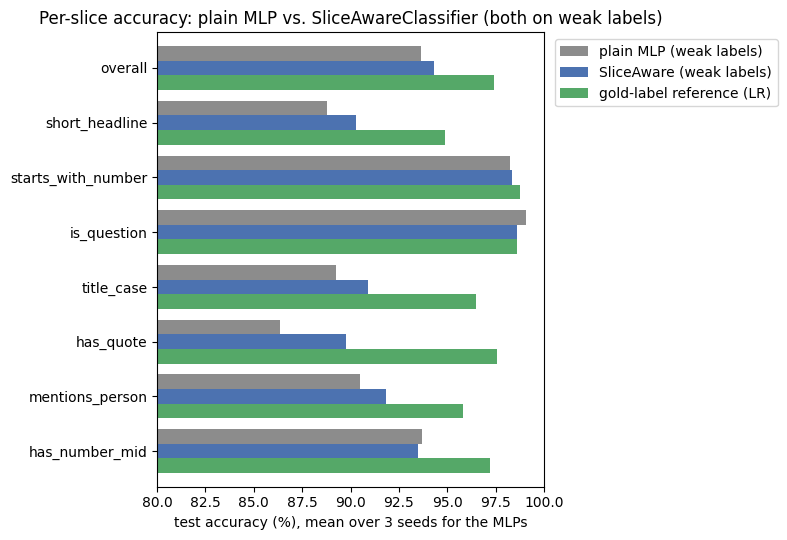

In [15]:
plot_df = final[["plain_MLP_acc_%", "SliceAware_acc_%", "gold_LR_acc_%"]]
ax = plot_df.plot.barh(figsize=(8, 5.5), color=["#8c8c8c", "#4C72B0", "#55A868"], width=0.8)
ax.set_xlim(80, 100)
ax.invert_yaxis()
ax.set_xlabel("test accuracy (%), mean over 3 seeds for the MLPs")
ax.set_title("Per-slice accuracy: plain MLP vs. SliceAwareClassifier (both on weak labels)")
ax.legend(["plain MLP (weak labels)", "SliceAware (weak labels)", "gold-label reference (LR)"],
          loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## Summary

**What we found**

| | overall | has_quote | title_case | short_headline | mentions_person |
|---|---|---|---|---|---|
| Gold-label LR (reference) | 97.4 | 97.6 | 96.5 | 94.9 | 95.8 |
| Weak-label LR (Part 1 pipeline) | 94.1 | 87.3 | 90.3 | 89.8 | 90.8 |
| Weak-label plain MLP | 93.6 | 86.4 | 89.3 | 88.8 | 90.5 |
| Weak-label **SliceAwareClassifier** | **94.3** | **89.8** | **90.9** | **90.3** | **91.8** |

* **Overall accuracy hides where weak supervision fails.** Weak labels cost 3.3 points overall but **10.2 points on headlines with quotes** and 5–6 points on Title-Case, short and person-mentioning headlines. The errors in the quote slice are almost all clickbait about TV shows and films ("The Trailer For "Star Trek Beyond" Shows Us A New Villain") predicted as NEWS: none of our Part 1 LFs targets pop-culture headlines.
* **The root cause is label quality.** Inside those slices the weak labels themselves are less accurate (≈93% vs 96% overall), and the end model inherits that.
* **Slice-aware learning helps where it's needed.** Compared with an identical MLP (tuned on validation, 3 seeds), the `SliceAwareClassifier` gains +0.7 overall and **+1.3 to +3.4 points on the four weakest slices**, with lower variance. It loses a little on two slices that were already near-perfect (`is_question` −0.5, `has_number_mid` −0.2).
* **It doesn't close the gap to gold labels** (89.8% vs 97.6% on `has_quote`). Modeling can only partly make up for bad labels. The most effective next step would be going back to Part 1 and writing LFs for the failing slices, e.g. *quoted title + Title Case + no news verb → CLICKBAIT*.

**MLOps takeaways**
* **Monitor slices, not just the overall score.** Weak supervision has a different cost for different subgroups, and overall accuracy hides that.
* **Keep a small gold-labeled sample around**, even in a weakly supervised pipeline. It's what let us find out that the problem comes from label quality in particular slices.
* **Compare like with like.** We compared the slice-aware model with an identical MLP, tuned both on validation data and averaged over seeds. Otherwise "the new model is better" could just come from architecture, tuning or luck.